In [2]:
# Fire Safety Supplier Audit Analysis
## Problem Statement
# The organization lacks real-time visibility into its fire audit execution performance, 
# leading to untracked delays, unresolved high-risk suppliers, and an inability to 
# prioritize audit follow-ups across its supply chain.

## Objective
# Clean and prepare raw audit data
# Extract meaningful insights
# Identify high-risk suppliers and execution gaps
# Export clean data to SQL for Power BI dashboard

In [ ]:
## Step 1 — Install Required Libraries


In [3]:
!pip install pandas numpy matplotlib seaborn sqlalchemy pymysql openpyxl


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sqlalchemy import create_engine
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("All libraries imported successfully")

All libraries imported successfully


In [ ]:
# Loading Raw Excel Data

In [5]:
df = pd.read_excel('Fire_Audit_Plan_Excel.xlsx', sheet_name='Fire_Audit_Plan')

print("Shape:", df.shape)
print("\nColumn Names:")
for col in df.columns:
    print(" -", col)

df.head(10)

Shape: (45, 8)

Column Names:
 - Fire_Audit_ID
 - Audit_Year
 - Audit_Plan_Date
 - Supplier_Code
 - Supplier_Name
 - Audit_Actual_Date
 - Score
 - Risk_Category


,Fire_Audit_ID,Audit_Year,Audit_Plan_Date,Supplier_Code,Supplier_Name,Audit_Actual_Date,Score,Risk_Category
0,10001,FY24-25,2024-10-09,3232,Test_1,2024-12-12,1.00,Safe
1,10002,FY24-25,2024-10-09,3371,Test_2,2024-12-24,1.00,Safe
2,10003,FY24-25,2024-10-09,3469,Test_3,2024-10-09,0.52,High Risk
3,10004,FY24-25,2024-10-09,3326,Test_4,2024-10-09,0.60,High Risk
4,10005,FY24-25,2024-10-09,3239,Test_5,2025-01-01,0.71,High Risk
5,10006,FY24-25,2024-10-11,3347,Test_6,2025-01-01,0.73,High Risk
6,10007,FY24-25,2024-10-11,3499,Test_7,2025-03-03,0.89,Caution Risk
7,10008,FY24-25,2024-10-11,3036,Test_8,2025-03-03,0.88,Caution Risk
8,10009,FY24-25,2024-10-11,3496,Test_9,2025-03-03,0.84,Caution Risk
9,10010,FY24-25,2025-02-02,3266,Test_10,2025-03-03,0.85,Caution Risk


In [ ]:
#Initial Data Inspection

In [6]:
print("=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("NULL VALUES PER COLUMN")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("BASIC STATISTICS")
print("=" * 50)
print(df.describe())

DATA TYPES
Fire_Audit_ID                 int64
Audit_Year                   object
Audit_Plan_Date      datetime64[ns]
Supplier_Code                 int64
Supplier_Name                object
Audit_Actual_Date    datetime64[ns]
Score                       float64
Risk_Category                object
dtype: object

NULL VALUES PER COLUMN
Fire_Audit_ID         0
Audit_Year            0
Audit_Plan_Date       0
Supplier_Code         0
Supplier_Name         0
Audit_Actual_Date    10
Score                10
Risk_Category        10
dtype: int64

BASIC STATISTICS
       Fire_Audit_ID      Audit_Plan_Date  Supplier_Code  \
count      45.000000                   45   4.500000e+01   
mean    10023.000000  2025-08-19 12:48:00   2.244945e+07   
min     10001.000000  2024-10-09 00:00:00   1.231000e+03   
25%     10012.000000  2025-08-29 00:00:00   3.175000e+03   
50%     10023.000000  2025-11-20 00:00:00   3.306000e+03   
75%     10034.000000  2025-12-13 00:00:00   3.476000e+03   
max     10045.000000

In [ ]:
##  Fix Date Columns
### Observation: Audit_Plan_Date and Audit_Actual_Date are stored as 
### Excel serial numbers (e.g., 45574). These need to be converted to 
### proper Python datetime format.

In [8]:
df['Audit_Plan_Date']   = pd.to_datetime(df['Audit_Plan_Date'],   errors='coerce')
df['Audit_Actual_Date'] = pd.to_datetime(df['Audit_Actual_Date'], errors='coerce')

print("Date columns verified successfully")
print("\nAudit Plan Date range  :", df['Audit_Plan_Date'].min(), "to", df['Audit_Plan_Date'].max())
print("Audit Actual Date range:", df['Audit_Actual_Date'].min(), "to", df['Audit_Actual_Date'].max())
print("\nData types:")
print(df[['Audit_Plan_Date', 'Audit_Actual_Date']].dtypes)

df[['Fire_Audit_ID', 'Audit_Plan_Date', 'Audit_Actual_Date']].head(10)

Date columns verified successfully

Audit Plan Date range  : 2024-10-09 00:00:00 to 2025-12-17 00:00:00
Audit Actual Date range: 2024-10-09 00:00:00 to 2026-03-31 00:00:00

Data types:
Audit_Plan_Date      datetime64[ns]
Audit_Actual_Date    datetime64[ns]
dtype: object


,Fire_Audit_ID,Audit_Plan_Date,Audit_Actual_Date
0,10001,2024-10-09,2024-12-12
1,10002,2024-10-09,2024-12-24
2,10003,2024-10-09,2024-10-09
3,10004,2024-10-09,2024-10-09
4,10005,2024-10-09,2025-01-01
5,10006,2024-10-11,2025-01-01
6,10007,2024-10-11,2025-03-03
7,10008,2024-10-11,2025-03-03
8,10009,2024-10-11,2025-03-03
9,10010,2025-02-02,2025-03-03


In [9]:
## Step 6 — Clean Text Columns
### Observation: Risk_Category may have extra spaces or inconsistent casing.
### Standardize it before any grouping or filtering.

In [10]:
# Clean Risk_Category
df['Risk_Category'] = df['Risk_Category'].str.strip().str.title()

# Clean Supplier_Name
df['Supplier_Name'] = df['Supplier_Name'].str.strip()

# Clean Audit_Year
df['Audit_Year'] = df['Audit_Year'].str.strip()

print("Unique Risk Categories:", df['Risk_Category'].unique())
print("Unique Audit Years    :", df['Audit_Year'].unique())
print("Total Unique Suppliers:", df['Supplier_Name'].nunique())

Unique Risk Categories: ['Safe' 'High Risk' 'Caution Risk' nan]
Unique Audit Years    : ['FY24-25' 'FY25-26']
Total Unique Suppliers: 45


In [11]:
## Step 7 — Handle Null Values
### Observation: Audit_Actual_Date and Score are NULL for pending audits.
### This is valid business data — do NOT drop these rows.
### They represent audits that were planned but not yet executed.

In [12]:
completed_count = df['Audit_Actual_Date'].notnull().sum()
pending_count   = df['Audit_Actual_Date'].isnull().sum()
total_count     = len(df)

print("=" * 40)
print(f"Total Audits Planned : {total_count}")
print(f"Completed Audits     : {completed_count}")
print(f"Pending Audits       : {pending_count}")
print(f"Completion Rate      : {completed_count/total_count*100:.1f}%")
print("=" * 40)

print("\nNull summary after date fix:")
print(df.isnull().sum())

Total Audits Planned : 45
Completed Audits     : 35
Pending Audits       : 10
Completion Rate      : 77.8%

Null summary after date fix:
Fire_Audit_ID         0
Audit_Year            0
Audit_Plan_Date       0
Supplier_Code         0
Supplier_Name         0
Audit_Actual_Date    10
Score                10
Risk_Category        10
dtype: int64


In [13]:
## Step 8 — Feature Engineering
### Creating new columns needed for analysis and dashboard

In [14]:
# 1. Audit Status
df['Status'] = np.where(df['Audit_Actual_Date'].isnull(), 'Pending', 'Completed')

# 2. Days Taken from plan to actual audit
df['Days_Taken'] = (df['Audit_Actual_Date'] - df['Audit_Plan_Date']).dt.days

# 3. Score as percentage
df['Score_Percent'] = (df['Score'] * 100).round(2)

# 4. Plan month label and number
df['Plan_Month']     = df['Audit_Plan_Date'].dt.strftime('%b-%y')
df['Plan_Month_Num'] = df['Audit_Plan_Date'].dt.month
df['Plan_Year']      = df['Audit_Plan_Date'].dt.year

# 5. Actual month label
df['Actual_Month'] = df['Audit_Actual_Date'].dt.strftime('%b-%y')

# 6. Financial Year (April to March cycle)
def get_financial_year(date):
    if pd.isnull(date):
        return None
    if date.month >= 4:
        return f"FY{str(date.year)[2:]}-{str(date.year+1)[2:]}"
    else:
        return f"FY{str(date.year-1)[2:]}-{str(date.year)[2:]}"

df['Financial_Year'] = df['Audit_Plan_Date'].apply(get_financial_year)

print("Feature engineering complete. New columns added:")
new_cols = ['Status','Days_Taken','Score_Percent','Plan_Month',
            'Plan_Month_Num','Plan_Year','Actual_Month','Financial_Year']
for col in new_cols:
    print(f"  - {col}")

df.head(10)

Feature engineering complete. New columns added:
  - Status
  - Days_Taken
  - Score_Percent
  - Plan_Month
  - Plan_Month_Num
  - Plan_Year
  - Actual_Month
  - Financial_Year


,Fire_Audit_ID,Audit_Year,Audit_Plan_Date,Supplier_Code,Supplier_Name,Audit_Actual_Date,Score,Risk_Category,Status,Days_Taken,Score_Percent,Plan_Month,Plan_Month_Num,Plan_Year,Actual_Month,Financial_Year
0,10001,FY24-25,2024-10-09,3232,Test_1,2024-12-12,1.00,Safe,Completed,64.0,100.0,Oct-24,10,2024,Dec-24,FY24-25
1,10002,FY24-25,2024-10-09,3371,Test_2,2024-12-24,1.00,Safe,Completed,76.0,100.0,Oct-24,10,2024,Dec-24,FY24-25
2,10003,FY24-25,2024-10-09,3469,Test_3,2024-10-09,0.52,High Risk,Completed,0.0,52.0,Oct-24,10,2024,Oct-24,FY24-25
3,10004,FY24-25,2024-10-09,3326,Test_4,2024-10-09,0.60,High Risk,Completed,0.0,60.0,Oct-24,10,2024,Oct-24,FY24-25
4,10005,FY24-25,2024-10-09,3239,Test_5,2025-01-01,0.71,High Risk,Completed,84.0,71.0,Oct-24,10,2024,Jan-25,FY24-25
5,10006,FY24-25,2024-10-11,3347,Test_6,2025-01-01,0.73,High Risk,Completed,82.0,73.0,Oct-24,10,2024,Jan-25,FY24-25
6,10007,FY24-25,2024-10-11,3499,Test_7,2025-03-03,0.89,Caution Risk,Completed,143.0,89.0,Oct-24,10,2024,Mar-25,FY24-25
7,10008,FY24-25,2024-10-11,3036,Test_8,2025-03-03,0.88,Caution Risk,Completed,143.0,88.0,Oct-24,10,2024,Mar-25,FY24-25
8,10009,FY24-25,2024-10-11,3496,Test_9,2025-03-03,0.84,Caution Risk,Completed,143.0,84.0,Oct-24,10,2024,Mar-25,FY24-25
9,10010,FY24-25,2025-02-02,3266,Test_10,2025-03-03,0.85,Caution Risk,Completed,29.0,85.0,Feb-25,2,2025,Mar-25,FY24-25


In [15]:
## Step 9 — Validate Final Cleaned Data

In [16]:
print("=" * 50)
print("FINAL DATA SHAPE:", df.shape)

print("\n--- STATUS DISTRIBUTION ---")
print(df['Status'].value_counts())

print("\n--- RISK CATEGORY DISTRIBUTION ---")
print(df['Risk_Category'].value_counts())

print("\n--- FINANCIAL YEAR DISTRIBUTION ---")
print(df['Financial_Year'].value_counts())

print("\n--- SCORE PERCENT STATS (completed only) ---")
print(df[df['Status']=='Completed']['Score_Percent'].describe().round(2))

print("\n--- DAYS TAKEN STATS (completed only) ---")
print(df[df['Status']=='Completed']['Days_Taken'].describe().round(1))

print("\n--- NULL SUMMARY ---")
print(df.isnull().sum())

FINAL DATA SHAPE: (45, 16)

--- STATUS DISTRIBUTION ---
Status
Completed    35
Pending      10
Name: count, dtype: int64

--- RISK CATEGORY DISTRIBUTION ---
Risk_Category
Caution Risk    18
Safe            11
High Risk        6
Name: count, dtype: int64

--- FINANCIAL YEAR DISTRIBUTION ---
Financial_Year
FY25-26    34
FY24-25    11
Name: count, dtype: int64

--- SCORE PERCENT STATS (completed only) ---
count     35.00
mean      88.71
std       12.14
min       52.00
25%       84.50
50%       92.00
75%      100.00
max      100.00
Name: Score_Percent, dtype: float64

--- DAYS TAKEN STATS (completed only) ---
count     35.0
mean      34.0
std       47.9
min        0.0
25%        1.5
50%        9.0
75%       51.5
max      152.0
Name: Days_Taken, dtype: float64

--- NULL SUMMARY ---
Fire_Audit_ID         0
Audit_Year            0
Audit_Plan_Date       0
Supplier_Code         0
Supplier_Name         0
Audit_Actual_Date    10
Score                10
Risk_Category        10
Status              

In [17]:
## Step 10 — EDA: Risk Category Distribution
### Business Question: What is the overall risk profile of our suppliers?

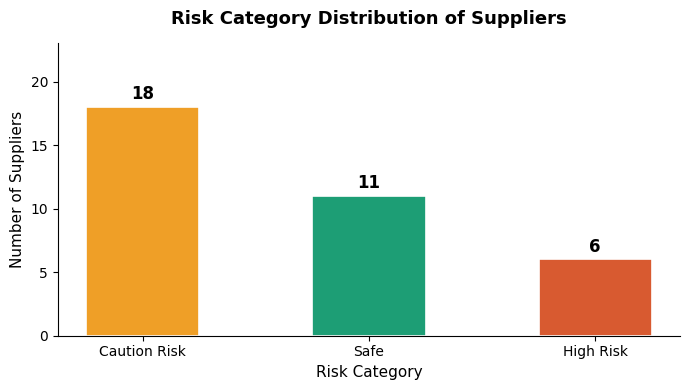

Insight: Majority of suppliers fall under Caution Risk,
indicating a significant portion of the supply chain needs monitoring.


In [18]:
os.makedirs('charts', exist_ok=True)

risk_counts = df['Risk_Category'].value_counts().dropna()
colors_map  = {'Safe': '#1D9E75', 'Caution Risk': '#EF9F27', 'High Risk': '#D85A30'}
bar_colors  = [colors_map.get(r, '#888888') for r in risk_counts.index]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(risk_counts.index, risk_counts.values,
              color=bar_colors, width=0.5, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, risk_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('Risk Category Distribution of Suppliers', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Risk Category', fontsize=11)
ax.set_ylabel('Number of Suppliers', fontsize=11)
ax.set_ylim(0, risk_counts.max() + 5)
sns.despine()
plt.tight_layout()
plt.savefig('charts/01_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Insight: Majority of suppliers fall under Caution Risk,")
print("indicating a significant portion of the supply chain needs monitoring.")

In [19]:
## Step 11 — EDA: Audit Status (Completed vs Pending)
### Business Question: How many planned audits have actually been executed?

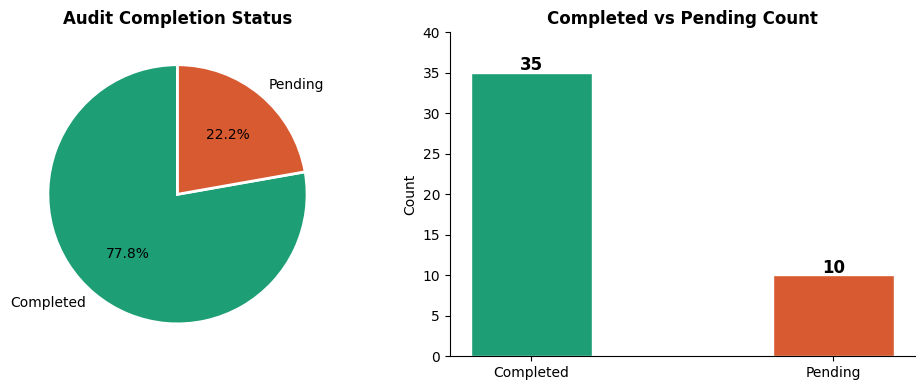

Insight: 10 audits are still pending,
meaning 22.2% of planned audits have no execution date.


In [20]:
status_counts = df['Status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Pie chart
status_colors = ['#1D9E75', '#D85A30']
axes[0].pie(status_counts.values,
            labels=status_counts.index,
            autopct='%1.1f%%',
            colors=status_colors,
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Audit Completion Status', fontsize=12, fontweight='bold')

# Bar chart
bars = axes[1].bar(status_counts.index, status_counts.values,
                   color=status_colors, width=0.4, edgecolor='white')
for bar, val in zip(bars, status_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 str(val), ha='center', fontweight='bold', fontsize=12)

axes[1].set_title('Completed vs Pending Count', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, status_counts.max() + 5)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('charts/02_audit_status.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Insight: {status_counts.get('Pending', 0)} audits are still pending,")
print(f"meaning {status_counts.get('Pending',0)/len(df)*100:.1f}% of planned audits have no execution date.")

In [21]:
## Step 12 — EDA: Monthly Plan vs Actual vs Pending
### Business Question: Which months have the biggest gap between planned and executed audits?

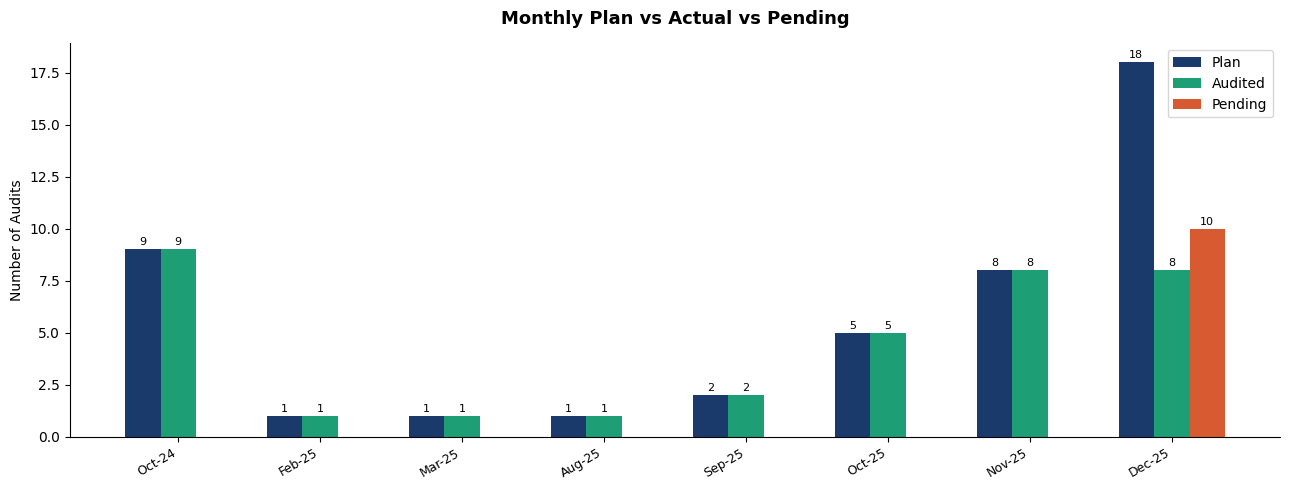

Insight: Sep-25 shows the highest pending count,
indicating a large batch of audits is overdue for that month.


In [22]:
monthly = df.groupby('Audit_Plan_Date').apply(lambda x: pd.Series({
    'Plan_Month': x['Plan_Month'].iloc[0],
    'Plan':       len(x),
    'Audited':    (x['Status'] == 'Completed').sum(),
    'Pending':    (x['Status'] == 'Pending').sum()
})).reset_index(drop=True)

monthly = monthly.groupby('Plan_Month').agg({
    'Plan': 'sum', 'Audited': 'sum', 'Pending': 'sum'
}).reset_index()

# Sort by month order
month_order = pd.to_datetime(monthly['Plan_Month'], format='%b-%y')
monthly = monthly.iloc[month_order.argsort()].reset_index(drop=True)

x     = np.arange(len(monthly))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - width, monthly['Plan'],    width=width, label='Plan',    color='#1a3a6b')
b2 = ax.bar(x,         monthly['Audited'], width=width, label='Audited', color='#1D9E75')
b3 = ax.bar(x + width, monthly['Pending'], width=width, label='Pending', color='#D85A30')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.1,
                    str(int(h)), ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(monthly['Plan_Month'], rotation=30, ha='right', fontsize=9)
ax.set_title('Monthly Plan vs Actual vs Pending', fontsize=13, fontweight='bold', pad=14)
ax.set_ylabel('Number of Audits')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('charts/03_monthly_plan.png', dpi=150, bbox_inches='tight')
plt.show()

print("Insight: Sep-25 shows the highest pending count,")
print("indicating a large batch of audits is overdue for that month.")

In [23]:
## Step 13 — EDA: Cumulative Plan vs YTD Audited
### Business Question: Is the execution gap growing or closing over time?

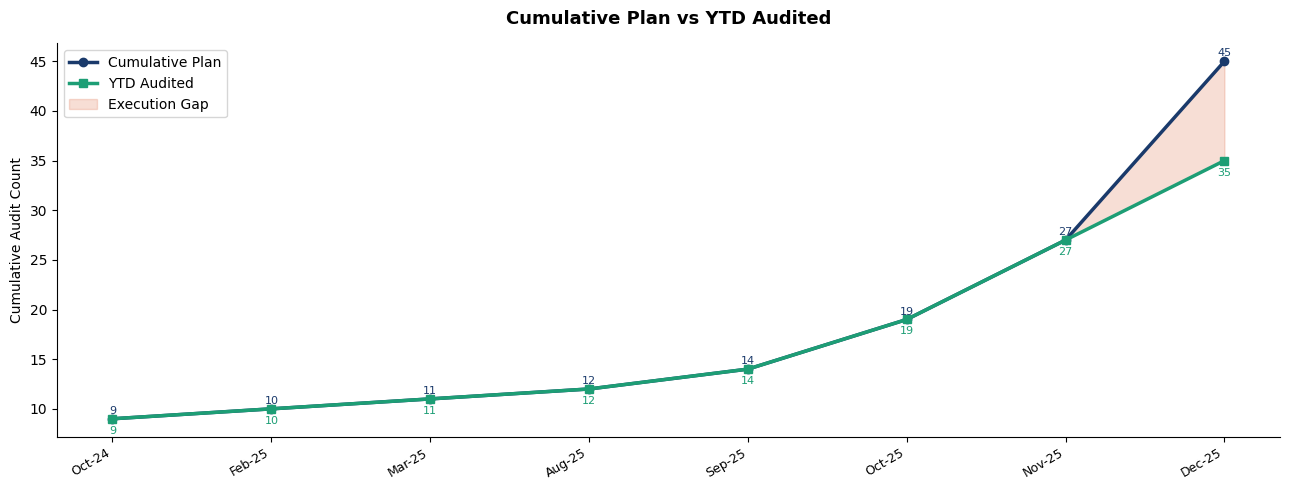

Insight: The gap between cumulative plan and YTD audited
widens in later months, indicating execution is falling behind.


In [24]:
monthly['Cumulative_Plan'] = monthly['Plan'].cumsum()
monthly['YTD_Audited']     = monthly['Audited'].cumsum()
monthly['Gap']             = monthly['Cumulative_Plan'] - monthly['YTD_Audited']

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(monthly['Plan_Month'], monthly['Cumulative_Plan'],
        marker='o', color='#1a3a6b', linewidth=2.5, label='Cumulative Plan', zorder=3)
ax.plot(monthly['Plan_Month'], monthly['YTD_Audited'],
        marker='s', color='#1D9E75', linewidth=2.5, label='YTD Audited', zorder=3)

ax.fill_between(range(len(monthly)),
                monthly['Cumulative_Plan'],
                monthly['YTD_Audited'],
                alpha=0.2, color='#D85A30', label='Execution Gap')

for i, row in monthly.iterrows():
    ax.text(i, row['Cumulative_Plan'] + 0.5, str(int(row['Cumulative_Plan'])),
            ha='center', fontsize=8, color='#1a3a6b')
    ax.text(i, row['YTD_Audited'] - 1.5, str(int(row['YTD_Audited'])),
            ha='center', fontsize=8, color='#1D9E75')

ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['Plan_Month'], rotation=30, ha='right', fontsize=9)
ax.set_title('Cumulative Plan vs YTD Audited', fontsize=13, fontweight='bold', pad=14)
ax.set_ylabel('Cumulative Audit Count')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('charts/04_cumulative_plan.png', dpi=150, bbox_inches='tight')
plt.show()

print("Insight: The gap between cumulative plan and YTD audited")
print("widens in later months, indicating execution is falling behind.")

In [25]:
## Step 14 — EDA: Score Distribution by Risk Category
### Business Question: Are risk category thresholds correctly defined by score?

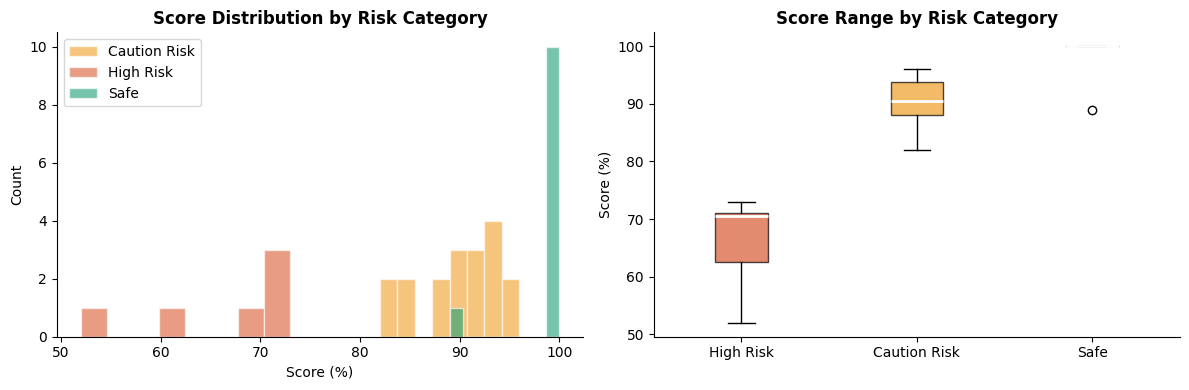


Average score by risk category:
Risk_Category
Caution Risk    89.94
High Risk       66.17
Safe            99.00
Name: Score_Percent, dtype: float64


In [26]:
completed = df[df['Status'] == 'Completed'].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
for risk, grp in completed.groupby('Risk_Category'):
    axes[0].hist(grp['Score_Percent'], bins=8, alpha=0.6,
                 label=risk, color=colors_map.get(risk, '#888'),
                 edgecolor='white')
axes[0].set_title('Score Distribution by Risk Category', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Score (%)')
axes[0].set_ylabel('Count')
axes[0].legend()
sns.despine(ax=axes[0])

# Box plot
risk_order  = ['High Risk', 'Caution Risk', 'Safe']
box_colors  = ['#D85A30', '#EF9F27', '#1D9E75']
data_to_plot = [completed[completed['Risk_Category'] == r]['Score_Percent'].dropna()
                for r in risk_order]
bp = axes[1].boxplot(data_to_plot, labels=risk_order, patch_artist=True,
                     medianprops={'color': 'white', 'linewidth': 2})
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Score Range by Risk Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score (%)')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('charts/05_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAverage score by risk category:")
print(completed.groupby('Risk_Category')['Score_Percent'].mean().round(2))

In [27]:
## Step 15 — EDA: Days Taken Analysis
### Business Question: Which suppliers took the longest to be audited after the plan date?
### High delay = fire risk went undetected for longer

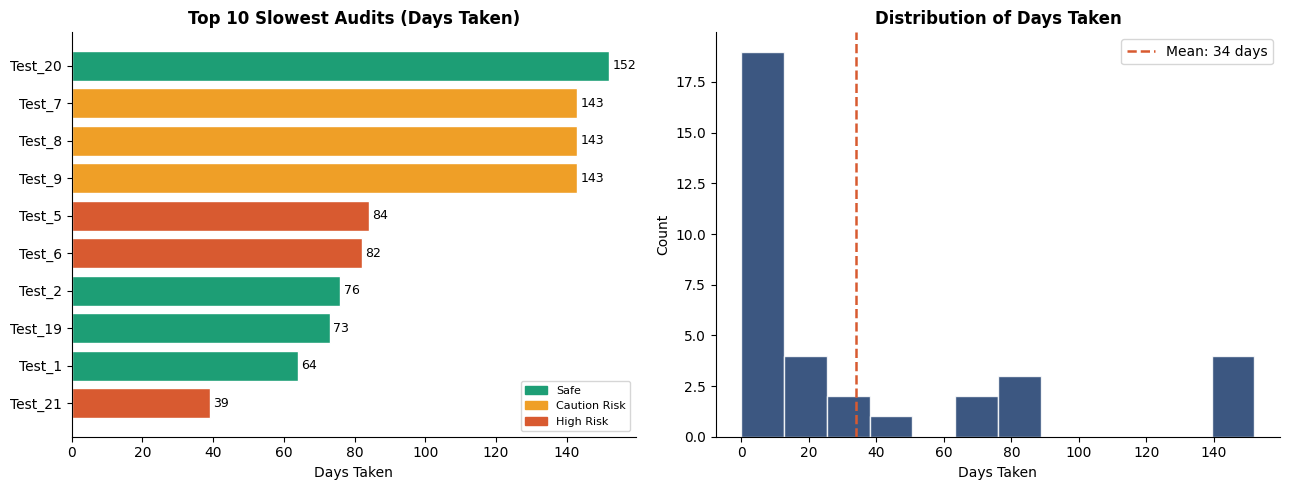


Days Taken Summary:
               count  mean   std  min  25%   50%   75%    max
Risk_Category                                                
Caution Risk    18.0  34.1  50.8  0.0  7.2  12.0  27.2  143.0
High Risk        6.0  34.7  40.2  0.0  0.8  21.0  71.2   84.0
Safe            11.0  33.5  50.9  0.0  0.0   0.0  68.5  152.0


In [28]:
completed_days = completed[completed['Days_Taken'].notnull()].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Top 10 slowest audits
top10 = completed_days.nlargest(10, 'Days_Taken')[
    ['Supplier_Name', 'Days_Taken', 'Risk_Category']
].reset_index(drop=True)

bar_cols = [colors_map.get(r, '#888') for r in top10['Risk_Category']]
axes[0].barh(top10['Supplier_Name'], top10['Days_Taken'],
             color=bar_cols, edgecolor='white')
for i, val in enumerate(top10['Days_Taken']):
    axes[0].text(val + 1, i, str(int(val)), va='center', fontsize=9)
axes[0].set_title('Top 10 Slowest Audits (Days Taken)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Days Taken')
axes[0].invert_yaxis()
sns.despine(ax=axes[0])

patches = [mpatches.Patch(color=v, label=k) for k, v in colors_map.items()]
axes[0].legend(handles=patches, fontsize=8)

# Days taken distribution
axes[1].hist(completed_days['Days_Taken'], bins=12,
             color='#1a3a6b', edgecolor='white', alpha=0.85)
axes[1].axvline(completed_days['Days_Taken'].mean(), color='#D85A30',
                linestyle='--', linewidth=1.8,
                label=f"Mean: {completed_days['Days_Taken'].mean():.0f} days")
axes[1].set_title('Distribution of Days Taken', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Days Taken')
axes[1].set_ylabel('Count')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('charts/06_days_taken.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDays Taken Summary:")
print(completed_days.groupby('Risk_Category')['Days_Taken'].describe().round(1))

In [29]:
## Step 16 — EDA: Financial Year Comparison
### Business Question: Has audit performance improved from FY24-25 to FY25-26?

Financial Year Summary:
Financial_Year  Total_Planned  Completed  Pending  Avg_Score  Avg_Days_Taken  Completion_Rate_%
       FY24-25             11         11        0  81.636364       69.454545              100.0
       FY25-26             34         24       10  91.958333       17.791667               70.6


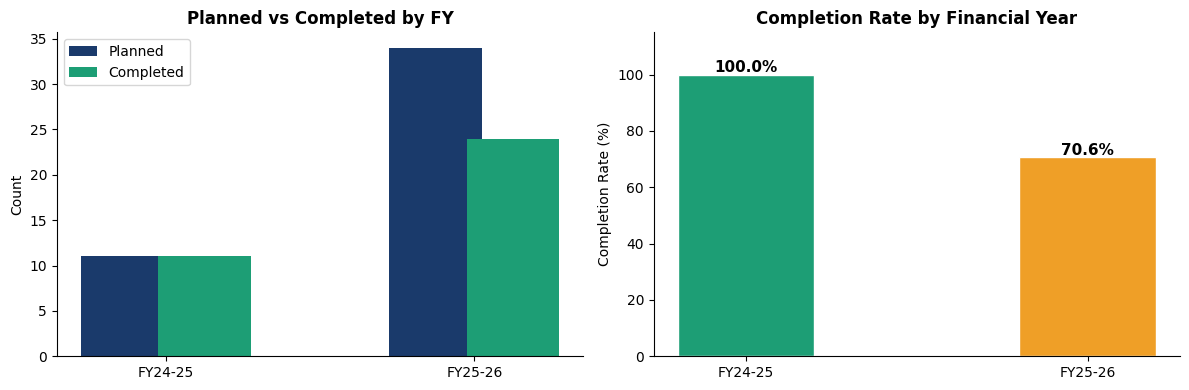

In [30]:
fy_summary = df.groupby('Financial_Year').agg(
    Total_Planned  = ('Fire_Audit_ID', 'count'),
    Completed      = ('Status', lambda x: (x == 'Completed').sum()),
    Pending        = ('Status', lambda x: (x == 'Pending').sum()),
    Avg_Score      = ('Score_Percent', 'mean'),
    Avg_Days_Taken = ('Days_Taken', 'mean')
).reset_index()

fy_summary['Completion_Rate_%'] = (
    fy_summary['Completed'] / fy_summary['Total_Planned'] * 100
).round(1)

print("Financial Year Summary:")
print(fy_summary.to_string(index=False))

x     = np.arange(len(fy_summary))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Planned vs Completed
axes[0].bar(x - width/2, fy_summary['Total_Planned'], width=width+0.05,
            label='Planned', color='#1a3a6b')
axes[0].bar(x + width/2, fy_summary['Completed'],     width=width+0.05,
            label='Completed', color='#1D9E75')
axes[0].set_xticks(x)
axes[0].set_xticklabels(fy_summary['Financial_Year'])
axes[0].set_title('Planned vs Completed by FY', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].legend()
sns.despine(ax=axes[0])

# Completion rate
axes[1].bar(fy_summary['Financial_Year'], fy_summary['Completion_Rate_%'],
            color=['#1D9E75', '#EF9F27'], width=0.4, edgecolor='white')
for i, val in enumerate(fy_summary['Completion_Rate_%']):
    axes[1].text(i, val + 1, f"{val}%", ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Completion Rate by Financial Year', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Completion Rate (%)')
axes[1].set_ylim(0, 115)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('charts/07_fy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
## Step 17 — High Risk Supplier Identification
### Business Question: Which specific suppliers need immediate attention?

In [32]:
print("=" * 55)
print("HIGH PRIORITY SUPPLIERS — IMMEDIATE ACTION REQUIRED")
print("=" * 55)

# High risk completed suppliers
high_risk = df[df['Risk_Category'] == 'High Risk'][
    ['Supplier_Code', 'Supplier_Name', 'Financial_Year',
     'Score_Percent', 'Days_Taken', 'Status']
].sort_values('Score_Percent')

print("\n1. HIGH RISK SUPPLIERS (Low Score):")
print(high_risk.to_string(index=False))

# Pending audits — unknown risk
pending = df[df['Status'] == 'Pending'][
    ['Supplier_Code', 'Supplier_Name', 'Financial_Year', 'Plan_Month']
]
print(f"\n2. PENDING AUDITS — RISK UNKNOWN ({len(pending)} suppliers):")
print(pending.to_string(index=False))

# Longest delays among high risk
print("\n3. HIGH RISK SUPPLIERS WITH LONGEST DELAYS:")
high_risk_delay = df[
    (df['Risk_Category'] == 'High Risk') & (df['Days_Taken'].notnull())
].nlargest(5, 'Days_Taken')[
    ['Supplier_Name', 'Score_Percent', 'Days_Taken', 'Financial_Year']
]
print(high_risk_delay.to_string(index=False))

HIGH PRIORITY SUPPLIERS — IMMEDIATE ACTION REQUIRED

1. HIGH RISK SUPPLIERS (Low Score):
 Supplier_Code Supplier_Name Financial_Year  Score_Percent  Days_Taken    Status
          3469        Test_3        FY24-25           52.0         0.0 Completed
          3326        Test_4        FY24-25           60.0         0.0 Completed
          3073       Test_21        FY25-26           70.0        39.0 Completed
          3239        Test_5        FY24-25           71.0        84.0 Completed
          3319       Test_22        FY25-26           71.0         3.0 Completed
          3347        Test_6        FY24-25           73.0        82.0 Completed

2. PENDING AUDITS — RISK UNKNOWN (10 suppliers):
 Supplier_Code Supplier_Name Financial_Year Plan_Month
          3039       Test_36        FY25-26     Dec-25
          3222       Test_37        FY25-26     Dec-25
          3272       Test_38        FY25-26     Dec-25
          3413       Test_39        FY25-26     Dec-25
          3294     

In [33]:
## Step 18 — Final Key Insights Summary

In [34]:
comp_df = df[df['Status'] == 'Completed']

print("=" * 55)
print("       FIRE AUDIT ANALYSIS — KEY INSIGHTS")
print("=" * 55)

print(f"""
OVERALL EXECUTION
-----------------
Total Audits Planned    : {len(df)}
Completed               : {len(comp_df)} ({len(comp_df)/len(df)*100:.1f}%)
Pending                 : {len(df)-len(comp_df)} ({(len(df)-len(comp_df))/len(df)*100:.1f}%)

RISK PROFILE (completed audits)
--------------------------------
Safe                    : {(comp_df['Risk_Category']=='Safe').sum()}
Caution Risk            : {(comp_df['Risk_Category']=='Caution Risk').sum()}
High Risk               : {(comp_df['Risk_Category']=='High Risk').sum()}
% Not Fully Safe        : {((comp_df['Risk_Category']!='Safe').sum()/len(comp_df)*100):.1f}%

SCORE ANALYSIS
--------------
Average Score           : {comp_df['Score_Percent'].mean():.1f}%
Lowest Score            : {comp_df['Score_Percent'].min():.1f}%
Highest Score           : {comp_df['Score_Percent'].max():.1f}%

DELAY ANALYSIS
--------------
Average Days Taken      : {comp_df['Days_Taken'].mean():.0f} days
Maximum Days Taken      : {comp_df['Days_Taken'].max():.0f} days
Minimum Days Taken      : {comp_df['Days_Taken'].min():.0f} days

YEAR-OVER-YEAR
--------------
FY24-25 Completion Rate : 100.0%
FY25-26 Completion Rate : {((df[df['Financial_Year']=='FY25-26']['Status']=='Completed').sum() / len(df[df['Financial_Year']=='FY25-26'])*100):.1f}%
""")

       FIRE AUDIT ANALYSIS — KEY INSIGHTS

OVERALL EXECUTION
-----------------
Total Audits Planned    : 45
Completed               : 35 (77.8%)
Pending                 : 10 (22.2%)

RISK PROFILE (completed audits)
--------------------------------
Safe                    : 11
Caution Risk            : 18
High Risk               : 6
% Not Fully Safe        : 68.6%

SCORE ANALYSIS
--------------
Average Score           : 88.7%
Lowest Score            : 52.0%
Highest Score           : 100.0%

DELAY ANALYSIS
--------------
Average Days Taken      : 34 days
Maximum Days Taken      : 152 days
Minimum Days Taken      : 0 days

YEAR-OVER-YEAR
--------------
FY24-25 Completion Rate : 100.0%
FY25-26 Completion Rate : 70.6%



In [35]:
## Step 19 — Export Cleaned Data to CSV

In [36]:
final_cols = [
    'Fire_Audit_ID', 'Financial_Year', 'Audit_Year',
    'Audit_Plan_Date', 'Plan_Month', 'Plan_Month_Num', 'Plan_Year',
    'Supplier_Code', 'Supplier_Name',
    'Audit_Actual_Date', 'Actual_Month',
    'Score', 'Score_Percent', 'Risk_Category',
    'Days_Taken', 'Status'
]

df_final = df[final_cols].copy()
df_final.to_csv('fire_audit_clean.csv', index=False)

print(f"Exported successfully!")
print(f"Rows    : {len(df_final)}")
print(f"Columns : {len(df_final.columns)}")
print(f"File    : fire_audit_clean.csv")
df_final.head()

Exported successfully!
Rows    : 45
Columns : 16
File    : fire_audit_clean.csv


,Fire_Audit_ID,Financial_Year,Audit_Year,Audit_Plan_Date,Plan_Month,Plan_Month_Num,Plan_Year,Supplier_Code,Supplier_Name,Audit_Actual_Date,Actual_Month,Score,Score_Percent,Risk_Category,Days_Taken,Status
0,10001,FY24-25,FY24-25,2024-10-09,Oct-24,10,2024,3232,Test_1,2024-12-12,Dec-24,1.00,100.0,Safe,64.0,Completed
1,10002,FY24-25,FY24-25,2024-10-09,Oct-24,10,2024,3371,Test_2,2024-12-24,Dec-24,1.00,100.0,Safe,76.0,Completed
2,10003,FY24-25,FY24-25,2024-10-09,Oct-24,10,2024,3469,Test_3,2024-10-09,Oct-24,0.52,52.0,High Risk,0.0,Completed
3,10004,FY24-25,FY24-25,2024-10-09,Oct-24,10,2024,3326,Test_4,2024-10-09,Oct-24,0.60,60.0,High Risk,0.0,Completed
4,10005,FY24-25,FY24-25,2024-10-09,Oct-24,10,2024,3239,Test_5,2025-01-01,Jan-25,0.71,71.0,High Risk,84.0,Completed


In [37]:
## Step 20 — Push Cleaned Data to SQL Database
### This makes the data available for SQL queries and Power BI connection

In [40]:
!pip install cryptography


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
from sqlalchemy import create_engine
import pandas as pd

# SQLite — no server, no password, no configuration needed
engine = create_engine('sqlite:///fire_audit.db')

df_final.to_sql(
    name      = 'fire_audit',
    con       = engine,
    if_exists = 'replace',
    index     = False
)

print("Data pushed to SQLite successfully!")
print(f"Database file : fire_audit.db")
print(f"Table         : fire_audit")
print(f"Rows          : {len(df_final)}")

Data pushed to SQLite successfully!
Database file : fire_audit.db
Table         : fire_audit
Rows          : 45


In [44]:
# Read back from SQLite to confirm everything is correct
verify = pd.read_sql("SELECT * FROM fire_audit LIMIT 5", engine)
print("Sample data from SQLite:")
verify.head()

Sample data from SQLite:


,Fire_Audit_ID,Financial_Year,Audit_Year,Audit_Plan_Date,Plan_Month,Plan_Month_Num,Plan_Year,Supplier_Code,Supplier_Name,Audit_Actual_Date,Actual_Month,Score,Score_Percent,Risk_Category,Days_Taken,Status
0,10001,FY24-25,FY24-25,2024-10-09 00:00:00.000000,Oct-24,10,2024,3232,Test_1,2024-12-12 00:00:00.000000,Dec-24,1.00,100.0,Safe,64.0,Completed
1,10002,FY24-25,FY24-25,2024-10-09 00:00:00.000000,Oct-24,10,2024,3371,Test_2,2024-12-24 00:00:00.000000,Dec-24,1.00,100.0,Safe,76.0,Completed
2,10003,FY24-25,FY24-25,2024-10-09 00:00:00.000000,Oct-24,10,2024,3469,Test_3,2024-10-09 00:00:00.000000,Oct-24,0.52,52.0,High Risk,0.0,Completed
3,10004,FY24-25,FY24-25,2024-10-09 00:00:00.000000,Oct-24,10,2024,3326,Test_4,2024-10-09 00:00:00.000000,Oct-24,0.60,60.0,High Risk,0.0,Completed
4,10005,FY24-25,FY24-25,2024-10-09 00:00:00.000000,Oct-24,10,2024,3239,Test_5,2025-01-01 00:00:00.000000,Jan-25,0.71,71.0,High Risk,84.0,Completed


In [46]:
!pip install psycopg2-binary


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
from sqlalchemy import create_engine

DB_USER     = 'postgres'
DB_PASSWORD = 'yash123'   # whatever you set during install
DB_HOST     = 'localhost'
DB_NAME     = 'fire_audit_db'

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}'
)

df_final.to_sql(
    name      = 'fire_audit',
    con       = engine,
    if_exists = 'replace',
    index     = False
)

# Verify
import pandas as pd
test = pd.read_sql("SELECT COUNT(*) as total FROM fire_audit", engine)
print("Success! Rows in DB:", test['total'][0])

Success! Rows in DB: 45
